In [ ]:
import os
import numpy as np
import logging
from PIL import Image
import torch
import random
import json

from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from transformers import (
    PaliGemmaProcessor,
    PaliGemmaForConditionalGeneration,
    Trainer,
    TrainingArguments,
    BitsAndBytesConfig,
)
import evaluate
from huggingface_hub import notebook_login


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


if torch.cuda.is_available():
    device = torch.device("cuda")
    logger.info(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    logger.info("GPU not available, using CPU instead.")


logger.info("Loading the clevr_cogen_a_train dataset...")

full_subset = load_dataset("leonardPKU/clevr_cogen_a_train", split="train[:3%]")


split_datasets = full_subset.train_test_split(test_size=0.1, seed=42)


train_dataset = split_datasets["train"]
test_dataset = split_datasets["test"]

logger.info(f"Training dataset size: {len(train_dataset)}")
logger.info(f"Testing dataset size: {len(test_dataset)}")

/home/moein_salimi/users/babak/IdeaGeneration/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:__main__:Using device: NVIDIA GeForce RTX 3090


INFO:__main__:Loading the clevr_cogen_a_train dataset...


INFO:__main__:Training dataset size: 1890


INFO:__main__:Testing dataset size: 210


Displaying 5 random samples from the training dataset...
--------------------------------------------------
--- Sample from Index: 556 ---


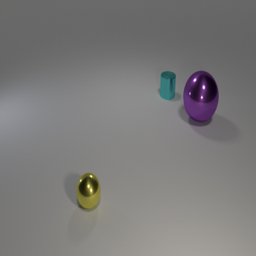

--------------------------------------------------
--- Sample from Index: 1508 ---


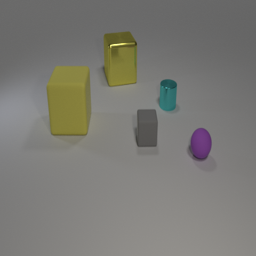

--------------------------------------------------
--- Sample from Index: 177 ---


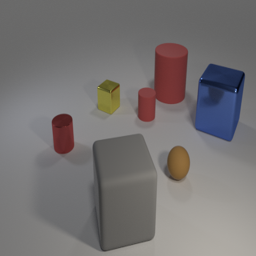

--------------------------------------------------
--- Sample from Index: 1403 ---


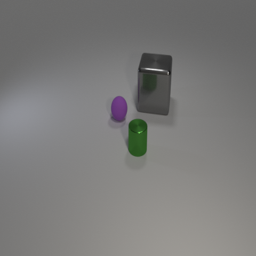

--------------------------------------------------
--- Sample from Index: 808 ---


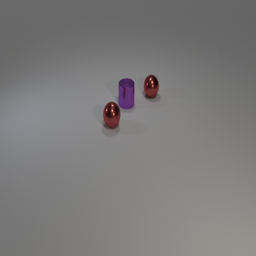

--------------------------------------------------


In [ ]:
import random
from IPython.display import display, HTML


print("Displaying 5 random samples from the training dataset...")
print("-" * 50)


num_samples_to_show = 5
random_indices = random.sample(range(len(train_dataset)), num_samples_to_show)


for index in random_indices:
    sample = train_dataset[index]

    print(f"--- Sample from Index: {index} ---")
    display(sample["image"].resize((256, 256)))

    display(
        HTML(
            f"""
    <ul>
        <li><b>Problem (Question):</b> {sample['problem']}</li>
        <li><b>Solution (Answer):</b> <code>{sample['solution']}</code></li>
    </ul>
    """
        )
    )
    print("-" * 50)

In [ ]:
import torch
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor
from peft import PeftModel
import os


base_model_id = "./paligemma-3b-mix-224"


local_checkpoint_path = "./paligemma-clevr-finetuned/checkpoint-788"
merged_model_path = "./final_merged_paligemma_model"


print("Loading base model in bfloat16 for merging...")
base_model = PaliGemmaForConditionalGeneration.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)


print("Loading processor...")
processor = PaliGemmaProcessor.from_pretrained(base_model_id)
merged_model_path = "./final_merged_paligemma_model"


print(f"Loading the final merged model from {merged_model_path}...")
model = PaliGemmaForConditionalGeneration.from_pretrained(
    merged_model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print("Merged model loaded successfully.")


processor = PaliGemmaProcessor.from_pretrained(merged_model_path)
print("Processor loaded successfully.")

Loading base model in bfloat16 for merging...


INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).



Loading checkpoint shards:   0%|                                                                                                           | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|█████████████████████████████████                                                                  | 1/3 [00:05<00:10,  5.23s/it]


Loading checkpoint shards:  67%|██████████████████████████████████████████████████████████████████                                 | 2/3 [00:08<00:04,  4.24s/it]

...


Loading checkpoint shards:  50%|█████████████████████████████████████████████████▌                                                 | 1/2 [00:04<00:04,  4.05s/it]


Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  1.88s/it]


Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.21s/it]

Merged model loaded successfully.


Processor loaded successfully.


In [ ]:
def preprocess_function(batch):
    questions = batch["problem"]
    images = batch["image"]
    answers = batch["solution"]

    processed_images = []
    texts_with_image = []

    for q, img in zip(questions, images):
        try:
            pil_img = img.convert("RGB").resize((224, 224))
            processed_images.append(pil_img)
            texts_with_image.append("<image> " + q)
        except Exception as e:
            logger.warning(f"Error processing an image, skipping it: {e}")
            processed_images.append(None)
            texts_with_image.append(None)

    valid_indices = [i for i, img in enumerate(processed_images) if img is not None]
    if not valid_indices:
        return {}

    processed_images = [processed_images[i] for i in valid_indices]
    texts_with_image = [texts_with_image[i] for i in valid_indices]
    valid_answers = [answers[i] for i in valid_indices]

    encoder_inputs = processor(
        images=processed_images,
        text=texts_with_image,
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )

    decoder_inputs = processor.tokenizer(
        text_target=valid_answers,
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )

    labels_ids = decoder_inputs["input_ids"].clone()
    padding_mask = decoder_inputs["attention_mask"] == 0
    labels_ids[padding_mask] = -100
    encoder_inputs["labels"] = labels_ids
    return encoder_inputs


logger.info("Applying preprocessing to the testing dataset...")
processed_test_dataset = test_dataset.map(
    preprocess_function, batched=True, remove_columns=test_dataset.column_names
)

INFO:__main__:Applying preprocessing to the testing dataset...


In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np


def custom_collate_fn(batch):
    collated_batch = {key: [] for key in batch[0].keys()}

    for sample in batch:
        for key in sample.keys():
            collated_batch[key].append(sample[key])

    for key in ["pixel_values", "input_ids", "labels"]:
        if key in collated_batch and collated_batch[key]:
            collated_batch[key] = torch.stack(
                [
                    item if torch.is_tensor(item) else torch.tensor(item)
                    for item in collated_batch[key]
                ]
            )

    return collated_batch


logger.info("Setting original test_dataset format to 'torch'...")
test_dataset.set_format("torch")


BATCH_SIZE = 8
logger.info(f"Parallelizing evaluation with a batch size of {BATCH_SIZE}...")

test_dataloader = DataLoader(
    processed_test_dataset, batch_size=BATCH_SIZE, collate_fn=custom_collate_fn
)
original_test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


EVAL_IMAGE_DIR = "evaluation_images_comparison"
os.makedirs(EVAL_IMAGE_DIR, exist_ok=True)
logger.info(f"Evaluation images will be saved in: {EVAL_IMAGE_DIR}")
rouge_metric = evaluate.load("rouge")


finetuned_model = model
finetuned_model.eval()

base_model.eval()

evaluation_results = []
batch_counter = 0


with torch.no_grad():
    for processed_batch, original_batch in tqdm(
        zip(test_dataloader, original_test_dataloader),
        total=len(test_dataloader),
        desc="Evaluating Batches",
    ):

        if hasattr(finetuned_model, "device_map") and finetuned_model.device_map:
            pixel_values = processed_batch["pixel_values"]
            input_ids = processed_batch["input_ids"]
        else:

            pixel_values = processed_batch["pixel_values"].to(device)
            input_ids = processed_batch["input_ids"].to(device)

        labels_list_batch = processed_batch["labels"]

        finetuned_outputs = finetuned_model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            max_new_tokens=50,
            early_stopping=True,
        )
        base_outputs = base_model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            max_new_tokens=50,
            early_stopping=True,
        )

        finetuned_prediction_texts = processor.tokenizer.batch_decode(
            finetuned_outputs, skip_special_tokens=True
        )
        base_prediction_texts = processor.tokenizer.batch_decode(
            base_outputs, skip_special_tokens=True
        )

        labels_for_decoding = labels_list_batch.clone()
        labels_for_decoding[labels_for_decoding == -100] = (
            processor.tokenizer.pad_token_id
        )
        label_texts = processor.tokenizer.batch_decode(
            labels_for_decoding, skip_special_tokens=True
        )

        for i in range(len(label_texts)):
            global_sample_idx = batch_counter * BATCH_SIZE + i

            image_tensor = original_batch["image"][i]

            image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

            image_np = (image_np * 255).astype(np.uint8)

            pil_image = Image.fromarray(image_np)

            image_path = os.path.join(
                EVAL_IMAGE_DIR, f"eval_image_{global_sample_idx}.png"
            )
            pil_image.save(image_path)

            evaluation_results.append(
                {
                    "image_path": image_path,
                    "question": original_batch["problem"][i],
                    "ground_truth": label_texts[i],
                    "finetuned_prediction": finetuned_prediction_texts[i],
                    "base_model_prediction": base_prediction_texts[i],
                }
            )
        batch_counter += 1


all_finetuned_preds = [res["finetuned_prediction"] for res in evaluation_results]
all_base_preds = [res["base_model_prediction"] for res in evaluation_results]
all_labels = [res["ground_truth"] for res in evaluation_results]

finetuned_rouge_results = rouge_metric.compute(
    predictions=all_finetuned_preds, references=all_labels
)
base_rouge_results = rouge_metric.compute(
    predictions=all_base_preds, references=all_labels
)

print("\n--- Quantitative Evaluation Results: Fine-Tuned vs. Base Model ---")
print("| Metric   | Fine-Tuned Model | Base Model |")
print("|----------|------------------|------------|")
print(
    f"| ROUGE-1  | {finetuned_rouge_results['rouge1']:.4f}           | {base_rouge_results['rouge1']:.4f}       |"
)
print(
    f"| ROUGE-2  | {finetuned_rouge_results['rouge2']:.4f}           | {base_rouge_results['rouge2']:.4f}       |"
)
print(
    f"| ROUGE-L  | {finetuned_rouge_results['rougeL']:.4f}           | {base_rouge_results['rougeL']:.4f}       |"
)
print("------------------------------------------------------------------\n")


output_eval_file = "full_evaluation_results_comparison.json"
with open(output_eval_file, "w") as f:
    json.dump(evaluation_results, f, indent=4)
logger.info(f"Full comparative evaluation results saved to {output_eval_file}")


print("\n--- Full Qualitative Evaluation Log (Fine-Tuned vs. Base Model) ---")
for result in evaluation_results:
    print(f"\n--- Image: {result['image_path']} ---")
    print(f"Question:              {result['question']}")
    print(f"Ground Truth:          {result['ground_truth']}")
    print(f"Base Model Prediction:   {result['base_model_prediction']}")
    print(f"Fine-Tuned Prediction: {result['finetuned_prediction']}")
    print("-" * 50)

INFO:__main__:Setting original test_dataset format to 'torch'...


INFO:__main__:Parallelizing evaluation with a batch size of 8...


INFO:__main__:Evaluation images will be saved in: evaluation_images_comparison



Evaluating Batches:   0%|                                                                                                                 | 0/27 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...


Evaluating Batches: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [01:22<00:00,  3.04s/it]


INFO:absl:Using default tokenizer.


INFO:absl:Using default tokenizer.


INFO:__main__:Full comparative evaluation results saved to full_evaluation_results_comparison.json



--- Quantitative Evaluation Results: Fine-Tuned vs. Base Model ---
| Metric   | Fine-Tuned Model | Base Model |
|----------|------------------|------------|
| ROUGE-1  | 0.0556           | 0.0937       |
| ROUGE-2  | 0.0000           | 0.0000       |
| ROUGE-L  | 0.0556           | 0.0937       |
------------------------------------------------------------------


--- Full Qualitative Evaluation Log (Fine-Tuned vs. Base Model) ---

--- Image: evaluation_images_comparison/eval_image_0.png ---
Question:              How many items are there in the image?
Ground Truth:          <answer> 9 </answer>
Base Model Prediction:    How many items are there in the image?
9
Fine-Tuned Prediction:  How many items are there in the image?
9
--------------------------------------------------

--- Image: evaluation_images_comparison/eval_image_1.png ---
Question:              How many items are there in the image?
Ground Truth:          <answer> 7 </answer>
Base Model Prediction:    How many items are 